In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
from numpy.typing import NDArray
from mad.objs.common_schemas import MovableObject
from dataclasses import dataclass, asdict, field
from mad.objs.planets import Planet, PlanetConfig
from mad.objs.constants import EARTH_SETTINGS, G
import matplotlib.pyplot as plt


In [40]:
obj1 = MovableObject(position=[1, 1])
obj2 = MovableObject(position=[1, 0])

obj1

MovableObject at [1 1], velocity [0 0], active.

In [41]:
obj1.magnitude, obj1.norm, obj1.distance(obj2)

(np.float64(1.4142135623730951),
 array([0.70710678, 0.70710678]),
 np.float64(1.0))

In [49]:
EARTH_SETTINGS["position"] = np.asarray([0.0, 0.0])

earth = Planet(PlanetConfig(**EARTH_SETTINGS))

earth.escape_velocity, earth.gravity_at_surface

(np.float64(11185.79353278485), np.float64(9.819649737724955))

In [51]:
@dataclass
class ProjectileConfig:
    position: list[float]
    mass: float
    velocity: list[float] | None = None
    name: str = "Projectile"
    area: float = 1 # m^2
    Cd: float = 0.47 # sphere

    @property
    def to_dict(self):
        return asdict(self)
    
    def __post_init__(self):
        if not self.velocity:
            self.velocity = [0.0] * len(self.position)

projectile_cfg = ProjectileConfig(
    **{"position": [earth.radius + 100, 0.0], "mass": 0.64, "velocity": [100, np.sqrt(G * earth.mass / earth.radius) * 1.1]}
)

@dataclass
class History:
    position: list = field(default_factory=list)
    velocity: list = field(default_factory=list)

In [80]:
class Projectile(MovableObject):
    def __init__(self, config: ProjectileConfig):
        super().__init__(config.position, config.velocity, config.mass, config.name)
        self.area = config.area
        self.Cd = config.Cd
        self.config = config
        self.history = History(position = [config.position], velocity = [config.velocity])

    def accelerations(self, planet):
        dist = self.distance(planet)
        total_forces = np.zeros_like(self.velocity)

        if dist > planet.radius:
            gravity_acc = planet.gravity_acc(self)
            gravity_f = - self.mass * gravity_acc
            total_forces += gravity_f
        else:
            self.active = False

        return total_forces / self.mass

    def step(self, dt: float, planet:Planet):

        acc = self.accelerations(planet)

        self.velocity += acc * dt
        self.position += self.velocity * dt

        self.history.position.append(self.position.tolist())
        self.history.velocity.append(self.velocity.tolist())



In [81]:
##Time window
period = 2 * np.pi / np.sqrt(G * earth.mass) * earth.radius ** (3.0 / 2.0) * 1.5

proj = Projectile(projectile_cfg)
dt = period / 1000
t = 0.0
time_scale = [t]
while (t < period) or (proj.active):
    proj.step(dt, planet=earth)
    time_scale.append(t)
    t += dt

In [82]:
pos = np.asarray(proj.history.position)
vel = np.asarray(proj.history.velocity)

posx, posz = pos[:, 0], pos[:, 1]
velx, velz = vel[:, 0], vel[:, 1]

altitude = np.sqrt(posx**2 + posz**2) - earth.radius
velout = np.sqrt(velx**2 + velz**2)

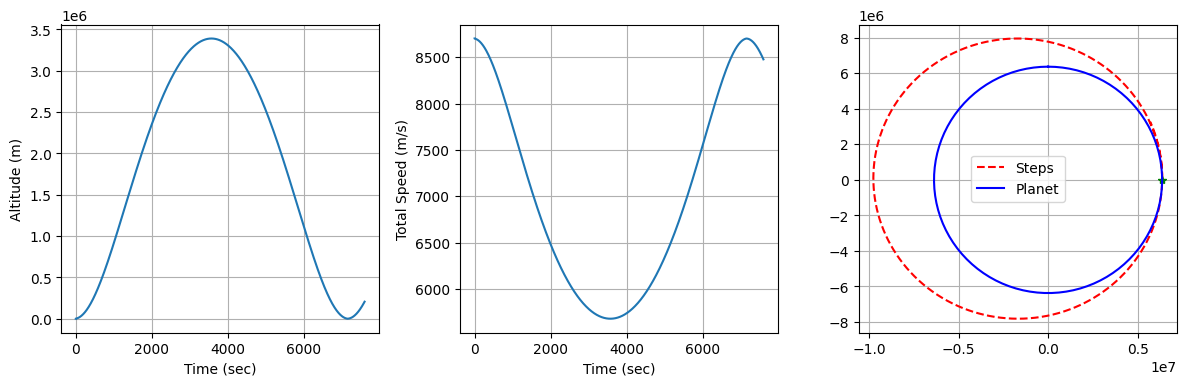

In [ ]:
fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(12, 4))
ax.flatten()

ax[0].plot(time_scale, altitude)
ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (ma)")
ax[0].grid()

ax[1].plot(time_scale, velout)
ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")
ax[1].grid()

ax[2].plot(posx, posz, "r--", label="Steps")
ax[2].plot(posx[0], posz[0], "g*")
theta = np.linspace(0, 2 * np.pi, 100)
xplanet = earth.radius * np.sin(theta)
yplanet = earth.radius * np.cos(theta)
ax[2].plot(xplanet, yplanet, "b-", label="Planet")
ax[2].grid()
ax[2].legend()

fig.tight_layout(pad=1.2)